# Unet for MNIST

## Imports

In [1]:
import sys
import os
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [ ]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Adam
import yaml

from src.dataset import get_mnist_dataloader
from src.models.unet import MnistUNet
from src.matching import OptimalTransportFlowMatcher

## Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")


with open("../configs/unet.yaml") as stream:
    model_config = yaml.safe_load(stream)
model = MnistUNet(**model_config).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)
flow_matcher = OptimalTransportFlowMatcher()

dataloader = get_mnist_dataloader(batch_size=64, is_train=True)

Device: mps


In [4]:
epochs = 50

model.train()
history_loss = []

print("Start Training.")
for epoch in range(epochs):
    epoch_loss = 0.0
        
    for batch in dataloader:
        x1 = batch[0].to(device)
        x0 = torch.randn_like(x1)
        
        t, x_t, v_t = flow_matcher.sample_location_and_target(x0, x1)
        v_pred = model(x_t, t)
        
        loss = F.mse_loss(v_pred, v_t)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        current_loss = loss.item()
        epoch_loss += current_loss
        
    avg_epoch_loss = epoch_loss / len(dataloader)
    history_loss.append(avg_epoch_loss)
    print(f"--> Epoch {epoch+1} over. Mean Loss : {avg_epoch_loss:.4f}")

Start Training.
--> Epoch 1 over. Mean Loss : 0.4070
--> Epoch 2 over. Mean Loss : 0.2558
--> Epoch 3 over. Mean Loss : 0.2365
--> Epoch 4 over. Mean Loss : 0.2264
--> Epoch 5 over. Mean Loss : 0.2192
--> Epoch 6 over. Mean Loss : 0.2152
--> Epoch 7 over. Mean Loss : 0.2099
--> Epoch 8 over. Mean Loss : 0.2081
--> Epoch 9 over. Mean Loss : 0.2052
--> Epoch 10 over. Mean Loss : 0.2034
--> Epoch 11 over. Mean Loss : 0.2002
--> Epoch 12 over. Mean Loss : 0.1990
--> Epoch 13 over. Mean Loss : 0.1972
--> Epoch 14 over. Mean Loss : 0.1959
--> Epoch 15 over. Mean Loss : 0.1943
--> Epoch 16 over. Mean Loss : 0.1936
--> Epoch 17 over. Mean Loss : 0.1925
--> Epoch 18 over. Mean Loss : 0.1913
--> Epoch 19 over. Mean Loss : 0.1900
--> Epoch 20 over. Mean Loss : 0.1894
--> Epoch 21 over. Mean Loss : 0.1893
--> Epoch 22 over. Mean Loss : 0.1878
--> Epoch 23 over. Mean Loss : 0.1874
--> Epoch 24 over. Mean Loss : 0.1861
--> Epoch 25 over. Mean Loss : 0.1865
--> Epoch 26 over. Mean Loss : 0.1853
--> E

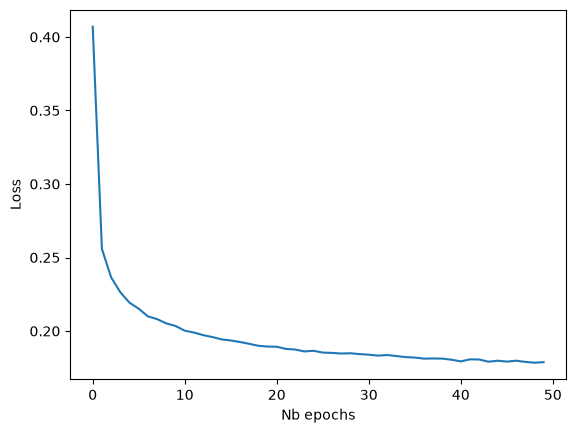

In [5]:
plt.figure()
plt.plot(history_loss)
plt.xlabel("Nb epochs")
plt.ylabel("Loss")
plt.show()

Better loss than the MLP:
- only 50 epochs to reach 0.18

However, an epoch here was longer than in the study 01, and we still see that, around the end, the model struggles to decrease its loss.

In [6]:
torch.save(model.state_dict(), "../artefacts/01_mnist_unet.pt")

## Results

In [7]:
model.eval()

num_samples = 8
steps = 100
dt = 1.0 / steps

x_gen = torch.randn(num_samples, 1, 28, 28).to(device)

with torch.no_grad():
    for step in range(steps):
        t_val = step * dt
        t_tensor = torch.full((num_samples,), t_val, device=device)
        
        v_pred = model(x_gen, t_tensor)
        
        x_gen = x_gen + v_pred * dt

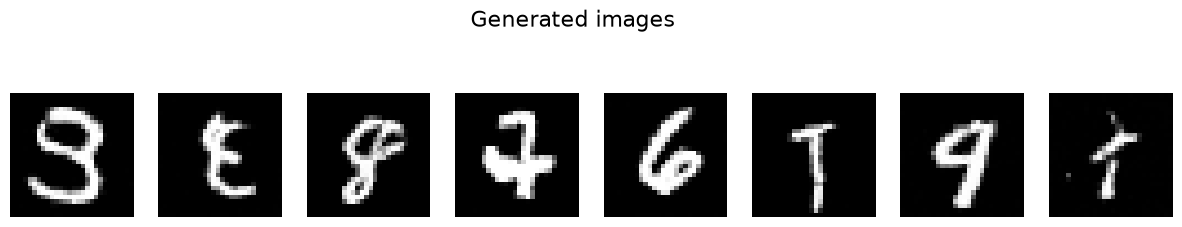

In [8]:
x_gen = x_gen.cpu().clamp(-1, 1)

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
for i in range(num_samples):
    img = (x_gen[i, 0] + 1) / 2 
    axes[i].imshow(img.numpy(), cmap="gray")
    axes[i].axis("off")

plt.suptitle("Generated images", fontsize=16)
plt.show()

It's better! The resolution is more clear and we even recognize some numbers, such as 6, 7 and 9. The other images are not real numbers from the data set but they still feel real.